# Figure 3.3-1 &mdash; the steam charts, drawn from Appendix A.III

Figure 3.3-1 is two full-page property charts for steam: **(a)** the
enthalpy&ndash;entropy or **Mollier** diagram, and **(b)** the temperature&ndash;entropy
diagram. This notebook draws both of them, and it draws them from the steam tables
printed in **Appendix A.III of this book** &mdash; so a value you read off a chart and a
value you look up in the table cannot disagree.

**Why run this rather than read the printed page?** A printed chart is one chart at one
scale. Here you can

- **zoom in** on the corner your problem lives in, at any scale you like, instead of
  reading a crowded full-page chart with a ruler;
- **read a number off the curve** instead of interpolating by eye &mdash; every family
  of lines is a function you can evaluate;
- **draw your own path** on the chart, as &sect;5 does for Illustration 3.4-1, and see
  the process rather than just its endpoints;
- **decide how busy the chart is.** Every line family is an argument. Turn the minor
  isobars off, put isotherms every 25 &deg;C instead of 50, and print the result.

**What this notebook does**

1. loads Appendix A.III as data, and checks the digitization against an identity the
   table must satisfy;
2. builds the four families of lines a property chart is made of &mdash; saturation,
   isobars, isotherms, constant quality (and constant enthalpy for the $T$&ndash;$S$
   chart);
3. draws both charts;
4. reads **Illustration 3.4-1** off them &mdash; the Joule&ndash;Thomson expansion the
   text solves *using these two figures* &mdash; and compares with the book's answer.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst<br>
August 2026

In [1]:
# --- Colab bootstrap -------------------------------------------------------
# No-op when the steam tables are already alongside this notebook (the normal
# case: you cloned the repository and are running from code/ch3/). In Colab
# there is no repository, so fetch the data directory.
import os, sys
if not (os.path.isdir('../data') or os.path.isdir('data')):
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/data .
DATA = '../data' if os.path.isdir('../data') else 'data'
# ---------------------------------------------------------------------------

## 1. Where the numbers come from, and why not an equation of state

The obvious way to draw a steam chart is from an equation of state. Two reasons not to:

- **A cubic will not do it.** The chapter 7 water notebook establishes that
  Peng&ndash;Robinson is **21% off** on the vapor pressure of water at the triple
  point, and $\hat H$ and $\hat S$ are harder than vapor pressure. A chart is read to
  better than 2%.
- **IAPWS-IF97 *would* do it, and is still the wrong choice here.** It is a few hundred
  lines with no new dependency. But it would create a **second source of truth**: a
  chart whose numbers disagree in the last digit with the appendix you are reading it
  against. These charts exist to be used for solving problems, and the problems are
  solved from A.III.

So the chart is drawn from A.III itself, which makes it **consistent with the table by
construction**. What A.III contains:

| | |
|---|---|
| saturation, temperature table | 71 rows, 0.01&ndash;374.14 &deg;C |
| saturation, pressure table | 73 rows |
| superheated vapor | **545 points** on **36 isobars** (0.01&ndash;60 MPa), 25 temperature levels (50&ndash;1300 &deg;C) |
| compressed liquid | 111 points on 6 isobars |
| saturated solid&ndash;vapor | 22 rows |

36 isobars is more than a classic Mollier chart plots.

&#9888; **Two things to know about this data.**

- **A.III is not IAPWS.** The appendix is reproduced in the book from Van Wylen &
  Sontag (Wiley, 1978), so it is that generation of steam tables and differs from
  current NIST values in the last digit or two. For a chart you read *against the
  appendix* that is not a defect, it is the requirement &mdash; but it does mean
  nothing drawn here may be labeled IAPWS. If A.III is ever updated, the chart
  regenerates for free.
- **The printed table groups digits with a thin space** (`0.194 44`, `0.001 285 9`).
  A whitespace tokenizer splits those in two and silently shifts every column to the
  right of them &mdash; producing corrupted isobars that still look like plausible
  curves. `tools/parse_appendix_A3.py`, which produced these CSVs, cuts columns by position
  rather than by counting tokens, and then verifies every row against
  $P\hat V = \hat H - \hat U$, which is the check the next cell repeats.

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
from shutil import which

# Appendix A.III, digitized: the four tables the charts are drawn from. DATA was
# set by the bootstrap cell above.
sat = pd.read_csv(f"{DATA}/steam_saturation_T.csv")     # the dome, vs temperature
sh = pd.read_csv(f"{DATA}/steam_superheat.csv")         # superheated vapor
cl = pd.read_csv(f"{DATA}/steam_compressed_liquid.csv")  # compressed liquid
solid = pd.read_csv(f"{DATA}/steam_solid_vapor.csv")     # saturated solid-vapor

print(f"reading Appendix A.III from {DATA}/")
print(f"  saturation : {len(sat)} rows, {sat.T_C.min()}-{sat.T_C.max()} C")
print(f"  superheat  : {len(sh)} points, {sh.P_MPa.nunique()} isobars, "
      f"{sh.T_C.nunique()} temperature levels")
print(f"  compr. liq.: {len(cl)} points, {cl.P_MPa.nunique()} isobars")

# Typography: a real LaTeX installation when there is one, so the figure is set in
# Computer Modern like the book; matplotlib's own mathtext otherwise, so the notebook
# still runs in Colab.
mpl.rcParams["text.usetex"] = which("latex") is not None
mpl.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",   # Computer Modern math for the no-TeX fallback
    "pdf.fonttype": 42,         # keep text as text in the PDF
    "ps.fonttype": 42,
})

reading Appendix A.III from ../data/
  saturation : 71 rows, 0.01-374.14 C
  superheat  : 545 points, 36 isobars, 25 temperature levels
  compr. liq.: 111 points, 6 isobars


### The check that catches a bad parse

Enthalpy, internal energy and volume are not independent: $\hat H = \hat U + P\hat V$.
Every row of the superheat and compressed-liquid tables must satisfy it, and the
saturation rows must also satisfy $\Delta\hat X = \hat X^{\mathrm V} - \hat X^{\mathrm L}$.
Neither identity involves any correlation or fit &mdash; they are arithmetic the printed
table has to obey, so a column that has been shifted by one cannot pass them.

In [3]:
def check_PV(df, label):
    """P*V = H - U for every row, in kJ/kg.  Returns the rows that fail."""
    d = df.dropna(subset=["V", "U", "H"]).copy()
    d["PV"] = d.P_MPa * 1e3 * d.V          # MPa * m3/kg = 1e3 kJ/kg
    d["H_minus_U"] = d.H - d.U
    d["error"] = d.PV - d.H_minus_U
    bad = d[d.error.abs() > np.maximum(0.35, 2e-3 * d.H_minus_U.abs())]
    print(f"{label}: {len(d)} rows checked, {len(bad)} fail")
    return bad[["P_MPa", "T_C", "V", "U", "H", "PV", "H_minus_U", "error"]]


bad_sh = check_PV(sh, "superheated vapor")
bad_cl = check_PV(cl, "compressed liquid ")
print()
print(pd.concat([bad_sh, bad_cl]).to_string(index=False,
                                            float_format=lambda v: f"{v:.4f}"))

superheated vapor: 545 rows checked, 2 fail
compressed liquid : 111 rows checked, 1 fail

  P_MPa       T_C      V         U         H       PV  H_minus_U     error
 3.5000  500.0000 0.0992 3103.0000 3450.9000 347.1300   347.9000   -0.7700
10.0000 1300.0000 0.0727 4460.5000 5387.0000 726.5000   926.5000 -200.0000
50.0000  240.0000 0.0011  990.7000 1049.2000  55.3600    58.5000   -3.1400


### Three rows fail, and all three are typos in the printed table

Not parse errors &mdash; each one is confirmed a second way, by its neighbors in the
same column:

| where | printed | should be | second witness |
|---|---|---|---|
| superheat, 3.5 MPa, 500 &deg;C | $\hat U$ = 3103.0 | **3103.8** | the 3.0 and 4.0 MPa rows interpolate to 3103.75 |
| superheat, 10.0 MPa, 1300 &deg;C | $\hat U$ = 4460.5 | **4660.5** | the 9.0 and 12.5 MPa rows give &asymp;4660 &mdash; a dropped digit |
| compressed liquid, 50 MPa, 240 &deg;C | $\hat V$ = 0.001 107 2 | **0.001 170 2** | the 220 and 260 &deg;C rows bracket it; two digits transposed |

Two more that no identity can catch, found by reading down a column:

| where | printed | should be | why |
|---|---|---|---|
| saturation pressure table, 1.4 MPa | $\hat H^{\mathrm V}$ = 2790.6 | **2790.0** | $\hat H^{\mathrm L} + \Delta\hat H$ = 2790.0, and the *superheat* page's own `Sat.` row for 1.4 MPa prints 2790.0 &mdash; the book contradicts itself |
| compressed liquid, 50 MPa, 60 &deg;C | $\hat S$ = 0.8502 | **&asymp;0.805** | two routes agree: its pressure neighbors (0.8206 at 20 MPa, 0.8154 at 30) extrapolate to 0.8050, and its own column read in temperature gives 0.8054. A 0/5 swap on 0.8054 |

**None of the five touches the charts below**, which are drawn from $\hat H$ and
$\hat S$ in the saturation *temperature* table and the superheat table. The CSVs keep
the printed values &mdash; they are a digitization of A.III, not a correction of it.
All five are recorded in the errata for the previous edition.

In [4]:
# A second, independent check: ten values typed by hand off the printed page, at
# pressures on both sides of the thin-space grouping that the parser has to rejoin.
printed = pd.DataFrame([
    #  P MPa    T C     V printed     U        H        S
    (  0.010,    50.0, 14.869,     2443.9,  2592.6,  8.1749),
    (  0.10,    100.0,  1.6958,    2506.7,  2676.2,  7.3614),
    (  1.00,    200.0,  0.2060,    2621.9,  2827.9,  6.6940),
    (  1.20,    250.0,  0.19234,   2704.2,  2935.0,  6.8294),   # 0.192 34
    (  2.00,    400.0,  0.15120,   2945.2,  3247.6,  7.1271),   # 0.151 20
    (  5.00,    500.0,  0.06857,   3091.0,  3433.8,  6.9759),   # 0.068 57
    ( 10.00,    650.0,  0.04101,   3338.2,  3748.2,  7.0398),   # 0.041 01, printed "0l"
    ( 20.00,    800.0,  0.02385,   3592.7,  4069.7,  7.0544),   # 0.023 85
    ( 40.00,    500.0,  0.005622,  2678.4,  2903.3,  5.4700),   # 0.005 622
    ( 60.00,   1300.0,  0.012215,  4551.4,  5284.3,  7.4837),   # 0.012 215
], columns=["P_MPa", "T_C", "V", "U", "H", "S"])

key = ["P_MPa", "T_C"]
merged = printed.merge(sh, on=key, suffixes=("_printed", "_parsed"))
assert len(merged) == len(printed), "a spot-check row did not survive the parse"
for c in ("V", "U", "H", "S"):
    merged[f"d{c}"] = merged[f"{c}_parsed"] - merged[f"{c}_printed"]

worst = max(merged[f"d{c}"].abs().max() for c in ("V", "U", "H", "S"))
print(merged[key + [f"{c}{s}" for c in ("V", "U", "H", "S")
                    for s in ("_printed", "_parsed")]].to_string(index=False))
print(f"\nlargest disagreement with the printed page: {worst:.3g}"
      f"  ({'exact to every printed digit' if worst == 0 else 'CHECK THIS'})")

 P_MPa    T_C  V_printed  V_parsed  U_printed  U_parsed  H_printed  H_parsed  S_printed  S_parsed
  0.01   50.0  14.869000 14.869000     2443.9    2443.9     2592.6    2592.6     8.1749    8.1749
  0.10  100.0   1.695800  1.695800     2506.7    2506.7     2676.2    2676.2     7.3614    7.3614
  1.00  200.0   0.206000  0.206000     2621.9    2621.9     2827.9    2827.9     6.6940    6.6940
  1.20  250.0   0.192340  0.192340     2704.2    2704.2     2935.0    2935.0     6.8294    6.8294
  2.00  400.0   0.151200  0.151200     2945.2    2945.2     3247.6    3247.6     7.1271    7.1271
  5.00  500.0   0.068570  0.068570     3091.0    3091.0     3433.8    3433.8     6.9759    6.9759
 10.00  650.0   0.041010  0.041010     3338.2    3338.2     3748.2    3748.2     7.0398    7.0398
 20.00  800.0   0.023850  0.023850     3592.7    3592.7     4069.7    4069.7     7.0544    7.0544
 40.00  500.0   0.005622  0.005622     2678.4    2678.4     2903.3    2903.3     5.4700    5.4700
 60.00 1300.0   0.01

## 2. From 616 tabulated points to the lines on a chart

A property chart is four or five families of curves, and each one is a different slice
of the same table.

| family | how it is built |
|---|---|
| **saturation** (the dome) | the saturation temperature table, read directly: 71 rows of $\hat H^{\mathrm L}, \hat H^{\mathrm V}, \hat S^{\mathrm L}, \hat S^{\mathrm V}$ |
| **isobars** | one column-block of the superheat table, plus its `Sat.` row as the point where the isobar meets the dome |
| **isotherms** | every isobar evaluated at one temperature |
| **constant quality** $x$ | the lever rule on the dome: $\hat H = \hat H^{\mathrm L} + x\,\Delta\hat H$ and $\hat S = \hat S^{\mathrm L} + x\,\Delta\hat S$ |
| **constant enthalpy** | inside the dome, the quality that gives $\hat H_0$ at each temperature; outside it, where each isobar crosses $\hat H_0$ |

Between the tabulated points the curves are filled in with a **monotone cubic**
(PCHIP), not an ordinary spline: the temperature levels are 50 &deg;C apart in places,
and an ordinary cubic overshoots at the tight bend where an isobar leaves the
saturation line. Monotone interpolation cannot invent a wiggle that the data does not
contain.

**Isotherms are the one family that cannot be read straight off the table.** A.III
lists the intermediate temperature levels only at the higher pressures &mdash; 350 &deg;C
first appears at 0.5 MPa, 450 &deg;C at 2.5, 550 &deg;C at 6.0, **650 &deg;C not until
9.0** &mdash; so an isotherm built from table rows stops in the middle of the chart.
Building it by evaluating each *isobar* at that temperature instead carries every
isotherm down to 0.01 MPa, the lowest pressure the table carries.

**And 0.01 MPa is still short of the right-hand edge** for every isotherm below about
350 &deg;C. Going further needs no new data either, because steam at those pressures is
very nearly an ideal gas, for which at fixed temperature

$$ \hat S(P) = \hat S(P_0) - \frac{R}{M}\ln\frac{P}{P_0}, \qquad \hat H(P) = \hat H(P_0) $$

*exactly* &mdash; an isotherm becomes horizontal. The next cell checks that
continuation against the table before the chart uses it.

In [5]:
TC, PC = 374.14, 22.09      # the critical point: the last row of the saturation table
HC, SC = 2099.3, 4.4298
R_M = 8.314462618 / 18.015268e-3 / 1e3   # R/M for water, kJ/(kg K)

ALL_P = tuple(sorted(sh.P_MPa.unique()))

# the dome, as smooth functions of temperature
dome = {c: PchipInterpolator(sat.T_C, sat[c]) for c in
        ("P_MPa", "Hl", "Hv", "Sl", "Sv", "dH", "dS")}
Tsat_of_P = PchipInterpolator(sat.P_MPa, sat.T_C)


def quality_line(x, T=None):
    """(S, H) along a line of constant quality x, swept up the dome (lever rule)."""
    T = np.linspace(sat.T_C.min(), TC, 400) if T is None else T
    return (dome["Sl"](T) + x * dome["dS"](T),
            dome["Hl"](T) + x * dome["dH"](T))


_isobar_cache = {}


def isobar(P, table=None, raw=False):
    """(S, H, T) up one isobar: its saturated-vapor anchor, then the superheat.

    raw=True returns the tabulated knots instead of the interpolated curve, for a
    caller that needs to join them to knots from another table before smoothing.
    """
    if table is None and (P, raw) in _isobar_cache:
        return _isobar_cache[(P, raw)]
    if table is None and P < ALL_P[0]:             # below the superheat table
        out = low_pressure_isobar(P)
        _isobar_cache[(P, raw)] = out
        return out
    t = sh if table is None else table
    g = t[t.P_MPa == P]
    if g.empty:
        raise KeyError(f"no isobar at P = {P} MPa; have {sorted(t.P_MPa.unique())}")
    anchor, g = g[g["sat"]], g[~g["sat"]].sort_values("T_C")
    T, S, H = g.T_C.to_numpy(), g.S.to_numpy(), g.H.to_numpy()
    if len(anchor):                        # start the curve on the dome
        T = np.r_[float(anchor.Tsat_C.iloc[0]), T]
        S = np.r_[float(anchor.S.iloc[0]), S]
        H = np.r_[float(anchor.H.iloc[0]), H]
    if raw:
        out = (S, H, T)
    else:
        fine = np.linspace(T.min(), T.max(), 400)
        out = (PchipInterpolator(T, S)(fine), PchipInterpolator(T, H)(fine), fine)
    if table is None:
        _isobar_cache[(P, raw)] = out
    return out


def extend_to_low_P(P, S, H, S_end):
    """Continue an isotherm below the lowest pressure the table carries (0.01 MPa).

    Needed because the table stops at 0.01 MPa, which on the Mollier frame is short
    of the right-hand edge for every isotherm below about 350 C. The continuation is
    not a fit: at these pressures steam is nearly an ideal gas, and for an ideal gas
    at fixed temperature

        S(P) = S(P0) - (R/M) ln(P/P0)        and        H(P) = H(P0),

    exactly. The small residual in H is kept by extrapolating it linearly in P from
    the two lowest tabulated isobars; the residual in S is smaller than the line
    width (both are checked in the next cell).
    """
    if S_end <= S[0]:
        return P, S, H
    dHdP = (H[1] - H[0]) / (P[1] - P[0])
    P_end = P[0] * np.exp(-(S_end - S[0]) / R_M)
    P_new = np.geomspace(P_end, P[0], 60)[:-1]
    return (np.r_[P_new, P],
            np.r_[S[0] - R_M * np.log(P_new / P[0]), S],
            np.r_[H[0] + dHdP * (P_new - P[0]), H])


P_TRIPLE = 0.0006113    # MPa. The triple point: the first row of the saturation
                        # pressure table, and the lowest pressure at which there is
                        # a saturated LIQUID at all. Below it the dome does not
                        # exist, so it is the floor for an isobar on this chart.


def low_pressure_isobar(P):
    """(S, H, T) for an isobar below 0.01 MPa, the lowest the superheat table carries.

    Not an extrapolation of the chart's own curves. At these pressures steam is very
    nearly an ideal gas, for which, at fixed temperature,

        S(P) = S(P0) - (R/M) ln(P/P0)        and        H(P) = H(P0)

    exactly. Every point is anchored on the nearest state the appendix does tabulate:
    below 45.81 C on the saturated vapor at that temperature, whose pressure is
    already at or below 0.01 MPa, and above it on the 0.01 MPa isobar. The two agree
    where they meet, because Psat(45.81 C) IS 0.01 MPa -- so the curve leaves the
    saturation line exactly at Tsat(P) and joins the tabulated data without a step.

    What this neglects is the residual pressure dependence of H, under 1.5 kJ/kg here:
    well below the width of the printed line, and the same approximation the isotherms
    are continued with, which is checked against the table two cells above.
    """
    if P < P_TRIPLE:
        raise ValueError(f"{P} MPa is below the triple point, {P_TRIPLE} MPa: there "
                         "is no saturated liquid, so no isobar to anchor on the dome")
    S0, H0, T0 = isobar(0.01)
    T_join = float(T0.min())                       # 45.81 C: where 0.01 MPa saturates

    Ta = np.linspace(float(Tsat_of_P(P)), T_join, 150)       # anchored on the dome
    Sa = dome["Sv"](Ta) + R_M * np.log(dome["P_MPa"](Ta) / P)
    keep = T0 >= T_join                                       # anchored on 0.01 MPa
    return (np.r_[Sa, S0[keep] + R_M * np.log(0.01 / P)],
            np.r_[dome["Hv"](Ta), H0[keep]],
            np.r_[Ta, T0[keep]])


def isotherm(T, extend_to=None):
    """(S, H, P) along one isotherm, from the dome out to low pressure.

    Built by evaluating every isobar at T, not by reading a row of the table. The
    table lists the intermediate temperature levels only at higher pressures --
    350 C first appears at 0.5 MPa, 450 C at 2.5, 550 C at 6.0, 650 C at 9.0 -- so
    a row-based isotherm at those temperatures stops in the middle of the chart.
    Interpolating along each isobar instead carries every isotherm down to 0.01 MPa.
    """
    pts = [(P, float(np.interp(T, Tl, S)), float(np.interp(T, Tl, H)))
           for P in ALL_P
           for S, H, Tl in [isobar(P)]
           if Tl.min() <= T <= Tl.max()]
    P, S, H = (np.array(a) for a in zip(*sorted(pts)))

    if T < TC:                             # anchor it on the dome
        P = np.r_[P, float(dome["P_MPa"](T))]
        S = np.r_[S, float(dome["Sv"](T))]
        H = np.r_[H, float(dome["Hv"](T))]
        o = np.argsort(P)
        P, S, H = P[o], S[o], H[o]

    lp = np.log10(P)                       # smooth in log P: an isotherm is nearly
    fine = np.linspace(lp.min(), lp.max(), 400)   # straight there
    S, H, P = (PchipInterpolator(lp, S)(fine), PchipInterpolator(lp, H)(fine),
               10 ** fine)
    if extend_to is not None:
        P, S, H = extend_to_low_P(P, S, H, extend_to)
    return S, H, P


def _dome_crossings(H0):
    """(P, S, T) where the line of constant enthalpy H0 meets the saturation curve.

    It can meet it more than once: the saturated-vapor enthalpy rises to a maximum
    of 2804 kJ/kg at 235 C and falls again, so H0 = 2600 leaves the dome at 54 C and
    re-enters it at 344 C.
    """
    T = np.linspace(sat.T_C.min(), TC, 4000)
    out = []
    for Hkey, Skey in (("Hv", "Sv"), ("Hl", "Sl")):
        f = dome[Hkey](T) - H0
        for i in np.nonzero(np.sign(f[:-1]) * np.sign(f[1:]) < 0)[0]:
            t = T[i] - f[i] * (T[i + 1] - T[i]) / (f[i + 1] - f[i])
            out.append((float(dome["P_MPa"](t)), float(dome[Skey](t)), float(t)))
    return out


def isenthalp(H0, isobars=ALL_P):
    """Segments of the line of constant enthalpy H0, as [(S, T, where), ...].

    Two things make this the fiddliest family on the chart, and both of them are
    about where a segment STOPS.

    A line of constant enthalpy runs through the two-phase region and out of it, and
    the two parts are computed from different tables -- the lever rule inside, the
    isobars outside -- so each part is closed on the exact point where the line meets
    the saturation curve. Without that they stop a few degrees short of it and the
    line visibly fails to cross the phase envelope.

    And the part outside the dome is sampled one point per isobar, so a pressure
    range where no tabulated isobar carries H0 breaks the line in two. At 2600 kJ/kg
    the line exists at 0.01 MPa and again from 17.5 MPa upward, and joining those
    into one polyline draws a chord clear across the chart. The points are therefore
    grouped into runs of CONSECUTIVE isobars, and each run is a separate segment.
    """
    isobars = tuple(sorted(isobars))
    crossings = _dome_crossings(H0)
    segments = []

    # --- inside the dome: the quality that gives H0 at each temperature ---
    T = np.linspace(sat.T_C.min(), TC, 300)
    inside = (dome["Hl"](T) <= H0) & (H0 <= dome["Hv"](T))
    if inside.sum() > 1:
        t = T[inside]
        x = (H0 - dome["Hl"](t)) / dome["dH"](t)
        S = dome["Sl"](t) + x * dome["dS"](t)
        for _, sc, tc in crossings:          # close it onto the saturation curve
            if t.min() - 3 <= tc <= t.max() + 3:
                t, S = np.r_[t, tc], np.r_[S, sc]
        o = np.argsort(t)
        segments.append((S[o], t[o], "wet"))

    # --- outside the dome: one point per isobar, grouped into consecutive runs ---
    def point_on(P):
        """(S, T) where the isobar at P has enthalpy H0, on either side of the dome.

        BOTH sides have to be searched. A line of constant enthalpy that leaves the
        dome on the LIQUID side continues as a compressed liquid, and at 1800 kJ/kg
        that is exactly where it spends the 19-30 MPa stretch: invisible to the
        superheat table, so the line came out in two pieces with a gap between them.
        Above the critical pressure the tabulated branch is preferred over the
        pressure-interpolated liquid one, which is the weaker of the two there.
        """
        pieces = ((merged_isobar(P),) if P >= PC
                  else (liquid_branch(P), isobar(P)))
        for piece in pieces:
            if piece is None:
                continue
            S, H, T = piece
            if H.min() <= H0 <= H.max():
                o = np.argsort(H)
                return (float(np.interp(H0, H[o], S[o])),
                        float(np.interp(H0, H[o], T[o])))
        return None

    runs, run = [], []
    for P in isobars:
        pt = point_on(P)
        if pt is not None:
            run.append((P, pt[0], pt[1]))
        elif run:
            runs.append(run)
            run = []
    if run:
        runs.append(run)

    # a run that ends next to the dome -- with no tabulated isobar between it and the
    # crossing -- gets the crossing itself, so the line arrives ON the saturation
    # curve and meets the segment inside it
    for pc, sc, tc in crossings:
        for r in runs:
            if pc < r[0][0] and not any(pc < P < r[0][0] for P in isobars):
                r.insert(0, (pc, sc, tc))
            elif pc > r[-1][0] and not any(r[-1][0] < P < pc for P in isobars):
                r.append((pc, sc, tc))

    for r in runs:                           # already ordered in pressure
        if len(r) > 1:
            _, S, T = (np.array(a) for a in zip(*r))
            segments.append((S, T, "superheat"))
    return segments


# A.III tabulates compressed liquid at 5, 10, 15, 20, 30 and 50 MPa only. Where a
# line is DERIVED from those columns rather than read off them, a printed typo would
# be inherited as a visible kink, so the two known bad cells are repaired here. The
# CSV still holds what the page prints -- this is the one place that departs from it.
CL_CORRECTIONS = {
    # (P MPa, T C, column): corrected value, and how it was established
    (50.0, 60.0, "S"): 0.8054,      # printed 0.8502. Its pressure neighbors give
                                    # 0.8050 and its own column in T gives 0.8054
    (50.0, 240.0, "V"): 0.0011702,  # printed 0.001 107 2; P*V = H - U gives 0.0011702
}

CL = cl[~cl["sat"]].copy()
for (P_, T_, col_), value_ in CL_CORRECTIONS.items():
    CL.loc[(CL.P_MPa == P_) & (CL.T_C == T_), col_] = value_


def liquid_branch(P):
    """(S, H, T) up the liquid side of an isobar, from the compressed-liquid table.

    An isobar at a pressure the compressed-liquid table does not carry -- including
    60 MPa, the highest on the chart -- would otherwise begin abruptly at 375 C,
    where the superheat table starts. Compressed-liquid properties are very nearly
    linear in pressure at fixed temperature, so the missing branches are filled in
    across pressure: an interpolation for 25, 35 and 40 MPa, and a one-column
    extrapolation for 60. The continuation check above tests that extrapolation
    against a table it is not built from.
    """
    cols, T = {"S": [], "H": []}, []
    for t, g in CL.groupby("T_C"):
        g = g.sort_values("P_MPa")
        p = g.P_MPa.to_numpy()
        if len(p) < 2 or P < p[0]:
            continue                       # no clamping: skip, rather than guess
        for name, out in cols.items():
            v = g[name].to_numpy()
            if P <= p[-1]:
                out.append(float(np.interp(P, p, v)))
            else:                          # linear in P beyond the last column
                out.append(float(v[-1] + (v[-1] - v[-2]) / (p[-1] - p[-2])
                                 * (P - p[-1])))
        T.append(t)
    if len(T) < 2:
        return None
    S, H, T = np.array(cols["S"]), np.array(cols["H"]), np.array(T)
    o = np.argsort(T)
    S, H, T = S[o], H[o], T[o]
    if P < PC:
        # The table's last row is 2-11 C below saturation, so the branch is closed on
        # the saturated liquid itself. That is not only tidier to draw: without it the
        # branch stops short in ENTHALPY too, and a line of constant enthalpy that
        # ends between the two never finds this isobar at all.
        Ts = float(Tsat_of_P(P))
        keep = T <= Ts
        S = np.r_[S[keep], float(dome["Sl"](Ts))]
        H = np.r_[H[keep], float(dome["Hl"](Ts))]
        T = np.r_[T[keep], Ts]
    return (S, H, T) if len(T) > 1 else None


_merged_cache = {}


def merged_isobar(P):
    """(S, H, T) for a SUPERCRITICAL isobar: compressed liquid and superheat joined.

    Above the critical pressure there is no phase change, so the two tables describe
    one curve and it must be drawn -- and searched -- as one. They overlap, liquid
    running to 380 C and superheat starting at 375, and the liquid knots within 1 C
    of the superheat table are dropped: that is where the pressure interpolation of
    the liquid side is weakest, since the isobars fan out near the critical point.

    Joining them also closes the 360-375 C hole at 25 MPa, where the compressed-liquid
    table has no row and the superheat table has not started.
    """
    if P in _merged_cache:
        return _merged_cache[P]
    Sk, Hk, Tk = isobar(P, raw=True)
    lb = liquid_branch(P)
    if lb is not None:
        keep = lb[2] < Tk.min() - 1
        Tk = np.r_[lb[2][keep], Tk]
        Sk = np.r_[lb[0][keep], Sk]
        Hk = np.r_[lb[1][keep], Hk]
    fine = np.linspace(Tk.min(), Tk.max(), 600)
    out = (PchipInterpolator(Tk, Sk)(fine), PchipInterpolator(Tk, Hk)(fine), fine)
    _merged_cache[P] = out
    return out


def wet_isobar(P, Hmin):
    """The wet-region part of an isobar on an H-S chart: a straight line.

    Inside the dome an isobar is also an isotherm, so dH = T dS with T constant.

    Returns None above the critical pressure, where there is no wet region at all.
    Without that guard, Tsat_of_P extrapolates past the end of the saturation table
    -- it reports a saturation temperature of 2025 C at 60 MPa -- and the dome
    interpolators are then evaluated far outside their range, which produced a
    segment reaching H = 5e9 kJ/kg. Almost all of those are so far off-scale they
    never showed; the 25 MPa one clipped through the top-left corner of the chart.
    """
    if P >= PC:
        return None
    T = float(Tsat_of_P(P))
    Sl, Sv = float(dome["Sl"](T)), float(dome["Sv"](T))
    Hl, Hv = float(dome["Hl"](T)), float(dome["Hv"](T))
    if Hv <= Hmin:
        return None
    x = np.array([max(0.0, (Hmin - Hl) / (Hv - Hl)), 1.0])
    return Sl + x * (Sv - Sl), Hl + x * (Hv - Hl)

### Checking the two continuations before drawing with them

Both charts draw a line or two beyond where the table stops, and neither is worth
drawing unless it can be checked first.

**The isotherms, below 0.01 MPa.** Predict the tabulated 0.01 MPa point from the
0.1 and 0.05 MPa points &mdash; a *longer* reach in $\ln P$ than any extension the
chart draws &mdash; and compare.

**The 60 MPa liquid branch, beyond the 50 MPa column.** This one has a better test
than a leave-one-out: extrapolate the compressed-liquid table to 60 MPa at 380
&deg;C, and compare with the *superheated* table's own 60 MPa entry at 375 &deg;C.
That is a different table, at a temperature the extrapolation never saw.

In [6]:
# Is the low-pressure continuation good enough to draw? Test it where the answer is
# known: predict the tabulated 0.01 MPa point from the 0.1 and 0.05 MPa points, and
# compare. That is a bigger extrapolation in log P than any the chart actually makes.
rows = []
for T in (100, 200, 300, 500, 800):
    g = sh[(sh.T_C == T) & sh.P_MPa.isin([0.1, 0.05, 0.01])].sort_values("P_MPa")
    (P0, S0, H0), (P1, S1, H1), (P2, S2, H2) = [
        (r.P_MPa, r.S, r.H) for r in g.itertuples()]   # 0.01, 0.05, 0.1 MPa:
    # predict P0 (the lowest) from the two above it, the direction the chart extends
    dHdP = (H2 - H1) / (P2 - P1)
    rows.append({"T (C)": T,
                 "S predicted": S1 - R_M * np.log(P0 / P1), "S table": S0,
                 "H predicted": H1 + dHdP * (P0 - P1), "H table": H0})

pred = pd.DataFrame(rows)
pred["dS"] = pred["S predicted"] - pred["S table"]
pred["dH"] = pred["H predicted"] - pred["H table"]
print(pred.to_string(index=False, float_format=lambda v: f"{v:9.4f}"))

# what those errors are worth on the page, on a 5 x 2200 frame drawn 7.5 x 9.5 in
print(f"\nworst error, as a fraction of a 1-point line width on the printed chart:")
print(f"  entropy  {pred.dS.abs().max():.4f} kJ/kg K  "
      f"-> {pred.dS.abs().max() / 5.0 * 7.5 * 72:.1f} pt")
print(f"  enthalpy {pred.dH.abs().max():.2f} kJ/kg     "
      f"-> {pred.dH.abs().max() / 2200 * 9.5 * 72:.1f} pt")

# --- and the 60 MPa liquid branch, against a table it was not built from ------
print("\n60 MPa liquid branch, extrapolated from the 30 and 50 MPa columns:")
for prop in ("S", "H"):
    p = CL.pivot_table(index="T_C", columns="P_MPa", values=prop)
    a, b = p.loc[380, 30.0], p.loc[380, 50.0]
    got = b + (b - a) / 20 * 10
    tab = sh[(sh.P_MPa == 60) & (sh.T_C == 375)][prop].iloc[0]
    print(f"  {prop} at 380 C -> {got:9.4f}   vs the SUPERHEAT table's 60 MPa "
          f"at 375 C: {tab:9.4f}   ({got - tab:+.4f})")
print("  (the two should not match exactly -- they are 5 C apart -- but they bracket"
      "\n   the join, which is what the chart needs)")

 T (C)  S predicted   S table  H predicted   H table        dS        dH
   100       8.4375    8.4479    2687.5400 2687.5000   -0.0104    0.0400
   200       8.9008    8.9038    2879.6200 2879.5000   -0.0030    0.1200
   300       9.2801    9.2813    3076.4600 3076.5000   -0.0012   -0.0400
   500       9.8974    9.8978    3489.1800 3489.1000   -0.0004    0.0800
   800      10.6280   10.6281    4159.1400 4159.0000   -0.0001    0.1400

worst error, as a fraction of a 1-point line width on the printed chart:
  entropy  0.0104 kJ/kg K  -> 1.1 pt
  enthalpy 0.14 kJ/kg     -> 0.0 pt

60 MPa liquid branch, extrapolated from the 30 and 50 MPa columns:
  S at 380 C ->    3.7146   vs the SUPERHEAT table's 60 MPa at 375 C:    3.7141   (+0.0004)
  H at 380 C -> 1701.1500   vs the SUPERHEAT table's 60 MPa at 375 C: 1699.5000   (+1.6500)
  (the two should not match exactly -- they are 5 C apart -- but they bracket
   the join, which is what the chart needs)


### Labeling: the part that is chart craft rather than thermodynamics

An unlabeled chart is a mesh of curves. Making it readable is two separate jobs:
tell the families apart, and say which line is which. The first is line weight and dash
pattern, which is one dictionary. The second needs a little machinery, because a label
has to sit **on** its own curve and be rotated to that curve's slope *as drawn on the
page* &mdash; not in data units, which would tilt every label wrongly the moment you
change the axis limits.

In [7]:
# The families must be distinguishable in black and white -- the book is printed
# that way -- so they differ in weight and dash pattern, not color. Each is drawn in
# two tiers: a labeled MAJOR set at the weights below, and an unlabelled MINOR set
# between them at the _minor weights. This is the one place to change how heavy any
# family is.
LW = {"sat": 1.7,                    # the saturation line: the chart's spine
      "P": 1.0, "P_minor": 0.4,      # isobars
      "T": 0.7, "T_minor": 0.3,      # isotherms
      "x": 0.7, "x_minor": 0.3,      # constant quality
      "H": 0.7, "H_minor": 0.3}      # constant enthalpy (the T-S chart)
GRAY, GRAY_MINOR = "0.40", "0.62"

# The grid is read as much as the curves are, so it gets the same two-tier
# treatment: a labeled major division, and five subdivisions inside it. Five is
# what makes the subdivisions land on round numbers -- 0.5/5 = 0.1 kJ/kg K and
# 100/5 = 20 kJ/kg -- which is the whole point of a grid you interpolate by eye.
GRID_MAJOR = dict(color="0.70", lw=0.45)
GRID_MINOR = dict(color="0.87", lw=0.25)


def chart_grid(ax, x_major, y_major, minors=5, label_size=7):
    """Rule the axes like chart paper."""
    ax.xaxis.set_major_locator(MultipleLocator(x_major))
    ax.yaxis.set_major_locator(MultipleLocator(y_major))
    if minors:
        ax.xaxis.set_minor_locator(AutoMinorLocator(minors))
        ax.yaxis.set_minor_locator(AutoMinorLocator(minors))
        ax.grid(True, which="minor", **GRID_MINOR)
    ax.grid(True, which="major", **GRID_MAJOR)
    ax.tick_params(labelsize=label_size)
    ax.tick_params(which="minor", length=2)
    ax.set_axisbelow(True)


def _angle(ax, x, y, i):
    """Local slope of a polyline at index i, in *display* degrees.

    Normalized to [-90, 90], so a curve stored right-to-left -- the saturation line is
    tabulated upward in temperature and so runs backwards in entropy -- does not come
    out with its label upside down.
    """
    j = [max(i - 1, 0), min(i + 1, len(x) - 1)]
    p = ax.transData.transform(np.column_stack([x[j], y[j]]))
    dx, dy = p[1] - p[0]
    a = float(np.degrees(np.arctan2(dy, dx)))
    return a - 180 if a > 90 else a + 180 if a < -90 else a


def label_at(ax, x, y, text, *, along, value, size=6.5, color="k", offset=(0, 0),
             pick="last", rotate=True):
    """Write `text` on the polyline where `along` ('x'|'y') crosses `value`.

    A curve can cross `value` more than once -- a line of constant quality crosses a
    given enthalpy on both the rising and the falling side of the dome -- so `pick`
    ('first', 'last', 'max_x', 'min_x') chooses which crossing to label.
    """
    c = x if along == "x" else y
    hits = np.nonzero((c[:-1] - value) * (c[1:] - value) <= 0)[0]
    if not len(hits):
        return False
    i = int({"first": hits[0], "last": hits[-1],
             "max_x": hits[np.argmax(x[hits])],
             "min_x": hits[np.argmin(x[hits])]}[pick])
    # interpolate the crossing rather than snapping to the vertex before it. On a
    # 400-point curve the difference is sub-pixel, but the straight wet-region
    # segment of an isobar has only TWO points, and snapping puts its label on the
    # end of the line instead of where it was asked for.
    f = 0.0 if c[i + 1] == c[i] else (value - c[i]) / (c[i + 1] - c[i])
    xc = x[i] + f * (x[i + 1] - x[i])
    yc = y[i] + f * (y[i + 1] - y[i])
    (xlo, xhi), (ylo, yhi) = sorted(ax.get_xlim()), sorted(ax.get_ylim())
    if not (xlo <= xc <= xhi and ylo <= yc <= yhi):
        return False
    ax.text(xc + offset[0], yc + offset[1], text, fontsize=size, color=color,
            ha="center", va="center", rotation=_angle(ax, x, y, i) if rotate else 0,
            rotation_mode="anchor", zorder=6,
            bbox=dict(fc="white", ec="none", pad=0.6, alpha=0.85))
    return True


def label_end(ax, x, y, text, *, size=6.5, color="k", end="last", ha="left"):
    """Write `text` at the first or last point of the polyline inside the axes."""
    (xlo, xhi), (ylo, yhi) = sorted(ax.get_xlim()), sorted(ax.get_ylim())
    inside = np.nonzero((x >= xlo) & (x <= xhi) & (y >= ylo) & (y <= yhi))[0]
    if not len(inside):
        return False
    i = int(inside[0] if end == "first" else inside[-1])
    ax.text(x[i], y[i], f" {text} ", fontsize=size, color=color, ha=ha,
            va="center", zorder=6,
            bbox=dict(fc="white", ec="none", pad=0.6, alpha=0.85))
    return True


def fmt_P(P):
    """The pressures on this chart span five decades: write the low end in kPa."""
    return f"{P * 1e3:.3g} kPa" if P < 0.01 else f"{P:g} MPa"

## 3. Figure 3.3-1(a) &mdash; the Mollier ($\hat H$&ndash;$\hat S$) diagram

The frame is the ASME chart's: entropy 4.5 to 9.5 kJ/(kg K), enthalpy 2000 to 4200
kJ/kg, on a full page &mdash; taller than it is wide. That window is not arbitrary: it
is the turbine-expansion region, which is what a Mollier diagram is *for*.

**Two tiers per family.** Each family is drawn twice: a **labeled major set**, heavier,
and an **unlabeled minor set** between them, lighter &mdash; so the chart is dense
enough to read a value off, without every line competing for attention. All six sets are
arguments, and `LW` holds the weights; between them they decide how busy the chart is.

- the **saturated-vapor line** is the heaviest line on the chart, because everything
  else is read relative to it;
- **isobars** are solid and black &mdash; 12 labeled, the remaining 24 of the table's 36
  as thin lines between. Inside the dome an isobar is a *straight* line, since there
  $\mathrm{d}\hat H = T\,\mathrm{d}\hat S$ at constant $T$;
- **isotherms** are gray: every 100 &deg;C labeled, every 50 &deg;C drawn;
- **constant-quality** lines are gray and dashed, every 0.05 labeled.

Isobars are labeled in a fan across the top and the isotherms in a **key column down
the right-hand side**, which is where the ASME chart puts them too &mdash; now that the
isotherms run to the right edge, that column is the only place their labels can go
without landing on top of the isobars.

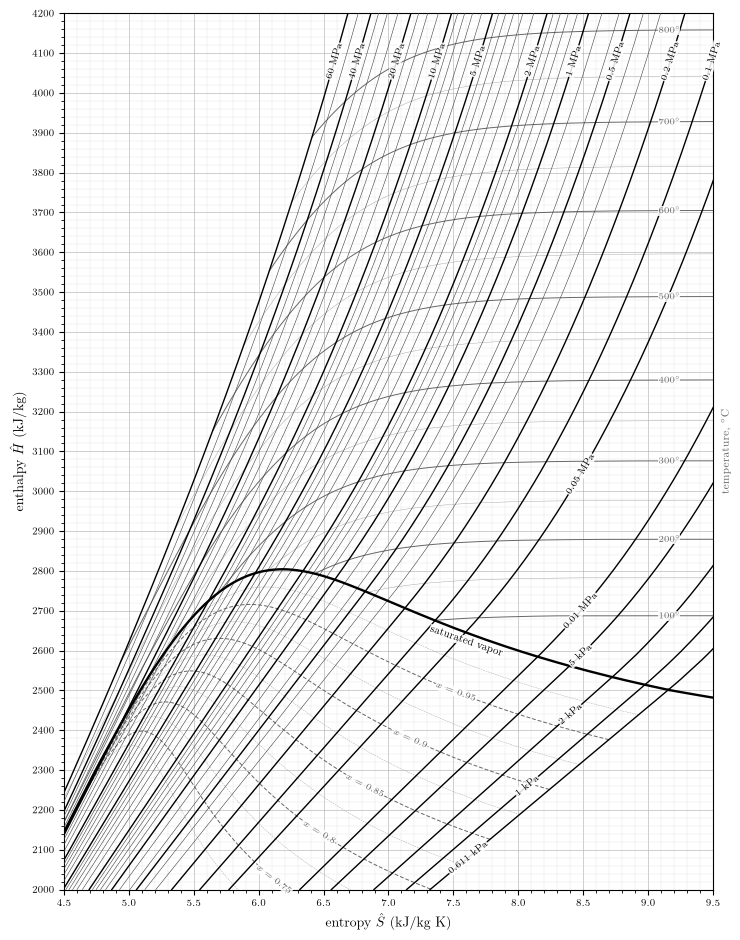

In [8]:
# Two tiers per family: a labeled major set, and an unlabelled minor set between
# them. Every set is a parameter -- together with LW above, this is where the chart's
# density is decided.
# Below 0.01 MPa the superheat table stops, but the chart does not: without these
# the whole lower-right corner is empty and the constant-quality lines stop in mid
# air. They end on the triple-point isobar, which is the last one here -- the lowest
# pressure at which steam has a saturated liquid at all.
MOLLIER_P = (P_TRIPLE, 0.001, 0.002, 0.005,
             0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 40.0, 60.0)
MOLLIER_P_MINOR = tuple(P for P in ALL_P if P not in MOLLIER_P)
MOLLIER_T = (100, 200, 300, 400, 500, 600, 700, 800)
MOLLIER_T_MINOR = (150, 250, 350, 450, 550, 650, 750)
MOLLIER_X = (0.75, 0.80, 0.85, 0.90, 0.95)
MOLLIER_X_MINOR = (0.725, 0.775, 0.825, 0.875, 0.925, 0.975)


def mollier(ax, *, S_lim=(4.5, 9.5), H_lim=(2000, 4200),
            isobars=MOLLIER_P, isobars_minor=MOLLIER_P_MINOR,
            isotherms=MOLLIER_T, isotherms_minor=MOLLIER_T_MINOR,
            qualities=MOLLIER_X, qualities_minor=MOLLIER_X_MINOR,
            label_H=4080, T_key=True, T_key_title=True, grid=True,
            S_grid=0.5, H_grid=100, grid_minors=5, x_label_between=(0.01, 0.05)):
    ax.set_xlim(*S_lim)          # limits first: labels are rotated in display space
    ax.set_ylim(*H_lim)
    S_edge = S_lim[1]

    # --- minor lines first, so the labeled majors sit on top of them ---
    for Tv in isotherms_minor:
        S, H, _ = isotherm(Tv, extend_to=S_edge)
        ax.plot(S, H, "-", color=GRAY_MINOR, lw=LW["T_minor"], zorder=1)
    for x in qualities_minor:
        S, H = quality_line(x)
        ax.plot(S, H, "--", color=GRAY_MINOR, lw=LW["x_minor"], zorder=1,
                dashes=(4, 2))
    for P in isobars_minor:
        S, H, _ = isobar(P)
        ax.plot(S, H, "-", color="0.25", lw=LW["P_minor"], zorder=3)
        seg = wet_isobar(P, H_lim[0])
        if seg:
            ax.plot(*seg, "-", color="0.25", lw=LW["P_minor"], zorder=3)

    # --- major isotherms, carried out to the right-hand edge ---
    S_key = S_lim[1] - 0.42            # x of the temperature key column
    for Tv in isotherms:
        S, H, _ = isotherm(Tv, extend_to=S_edge)
        ax.plot(S, H, "-", color=GRAY, lw=LW["T"], zorder=2)
        if T_key and S.max() >= S_key:
            # the isotherm is stored from high pressure to low, so entropy runs
            # DOWN the array: flip it for np.interp, which needs increasing x
            ax.text(S_key, float(np.interp(S_key, S[::-1], H[::-1])),
                    f"{Tv}$^\\circ$", fontsize=6.5, color=GRAY, ha="left",
                    va="center", zorder=6,
                    bbox=dict(fc="white", ec="none", pad=0.6, alpha=0.85))
        else:
            label_end(ax, S, H, f"{Tv}$^\\circ$C", color=GRAY)
    if T_key and T_key_title:      # off for small panels: it lands in the margin
        ax.text(1.012, 0.5, "temperature, $^\\circ$C", transform=ax.transAxes,
                rotation=90, ha="left", va="center", fontsize=7.5, color=GRAY)

    # --- major constant-quality lines ---
    # A point of a constant-quality line at temperature T lies exactly ON the isobar
    # whose saturation temperature is T -- inside the dome the isobar IS the T tie
    # line. So labeling the whole family at one temperature puts every label on one
    # isobar, and labeling at the mean of two pressures runs them up the band
    # between those two isobars, which is where the ASME chart puts its moisture
    # labels: out of the crowded left-hand fan and clear of the isobar labels.
    T_xlab = float(Tsat_of_P(np.sqrt(x_label_between[0] * x_label_between[1])))
    for x in qualities:
        S, H = quality_line(x)
        ax.plot(S, H, "--", color=GRAY, lw=LW["x"], zorder=2, dashes=(4, 2))
        H_lab = float(dome["Hl"](T_xlab) + x * dome["dH"](T_xlab))
        label_at(ax, S, H, f"$x$ = {x:g}", along="y", value=H_lab, color=GRAY,
                 pick="max_x")

    # --- major isobars, labeled in a fan across the top ---
    low = [P for P in isobars if P < ALL_P[0]]      # the sub-0.01 MPa group
    for P in isobars:
        S, H, _ = isobar(P)
        ax.plot(S, H, "-", color="k", lw=LW["P"], zorder=4)
        seg = wet_isobar(P, H_lim[0])
        if seg:
            ax.plot(*seg, "-", color="k", lw=LW["P"], zorder=4)
        # three places to put the label, in order of preference: the fan across the
        # top; on the line itself for an isobar that leaves through the RIGHT edge,
        # clear of the temperature key column; and, for the lowest pressures of all,
        # whose superheat branch starts too far right to reach either, on the
        # straight wet-region segment -- staggered in enthalpy so they do not collide
        if label_at(ax, S, H, fmt_P(P), along="y", value=label_H):
            continue
        if label_at(ax, S, H, fmt_P(P), along="x", value=S_key - 0.6):
            continue
        if seg and P in low:
            label_at(ax, seg[0], seg[1], fmt_P(P), along="y",
                     value=2080 + 180 * low.index(P))

    # --- the saturation line, heaviest ---
    T = np.linspace(sat.T_C.min(), TC, 500)
    Ssat, Hsat = dome["Sv"](T), dome["Hv"](T)
    ax.plot(Ssat, Hsat, "-", color="k", lw=LW["sat"], zorder=5)
    # Past the triple point the vapor is saturated with respect to ICE, not liquid,
    # and A.III tabulates that too. Drawing it carries the line off the edge of the
    # frame instead of letting it stop in mid-air at the triple point.
    sub = solid.sort_values("T_C")
    ax.plot(sub.Sv, sub.Hv, "-", color="k", lw=LW["sat"], zorder=5)
    label_at(ax, Ssat, Hsat, "saturated vapor", along="x", value=7.6, size=7,
             offset=(0, -22))

    if grid:
        chart_grid(ax, S_grid, H_grid, grid_minors)
    ax.set_xlabel(r"entropy  $\hat S$  (kJ/kg K)")
    ax.set_ylabel(r"enthalpy  $\hat H$  (kJ/kg)")
    return ax


fig, ax = plt.subplots(figsize=(7.5, 9.5))     # a full book page: height > width
mollier(ax)
fig.tight_layout()
os.makedirs("pdf", exist_ok=True)
fig.savefig("pdf/Fig_3.3-1a.pdf")     # the printed figure
plt.show()

## 4. Figure 3.3-1(b) &mdash; the temperature&ndash;entropy diagram

Same data, different projection, and it comes free: the saturation table is already
tabulated *against temperature*, so the dome is a direct plot. The frame is Keenan's:
entropy 0 to 10, temperature 0 to 800 &deg;C.

Two things this projection shows that the Mollier diagram cannot:

- inside the dome an isobar is **horizontal** &mdash; boiling at constant pressure is
  boiling at constant temperature. It is the same physical fact that makes the isobar
  straight on the Mollier chart, but here you can see it without being told.
- the compressed-liquid isobars, taken from the compressed-liquid table, pile onto the
  saturated-liquid line. That is the graphical version of the approximation the text
  uses constantly: for a liquid far from its critical point, properties barely depend
  on pressure.

The light curves are lines of **constant enthalpy** &mdash; the ones Illustration 3.4-1
follows in part (b). Inside the dome they are labeled *on the line*, in a row at
60 &deg;C: a line that never leaves the two-phase region runs down to the bottom of the
frame, so labeling it at its right-hand end would print the number on the temperature
axis. One member of the family is named as well as numbered &mdash; on the descending sweep of
the 3200 line, where the tilt makes it read as a label on that family &mdash; because
otherwise nothing on the chart says what 400 &hellip; 4000 are counting.

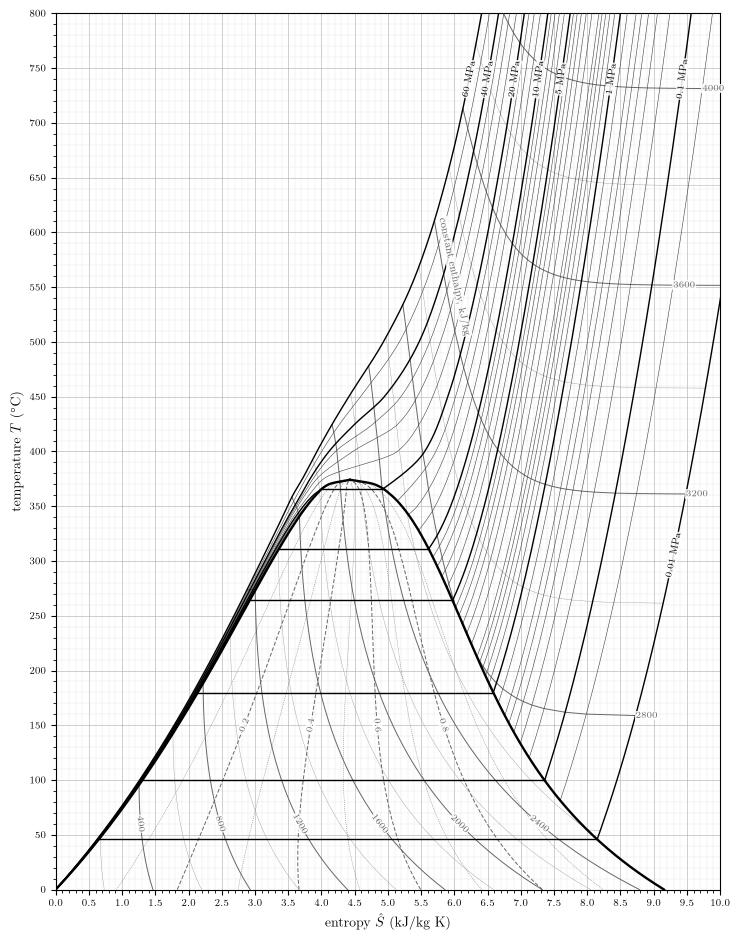

In [9]:
TS_P = (0.01, 0.1, 1.0, 5.0, 10.0, 20.0, 40.0, 60.0)
TS_P_MINOR = tuple(P for P in ALL_P if P not in TS_P)
TS_H = (400, 800, 1200, 1600, 2000, 2400, 2800, 3200, 3600, 4000)
TS_H_MINOR = (200, 600, 1000, 1400, 1800, 2200, 2600, 3000, 3400, 3800)
TS_X = (0.2, 0.4, 0.6, 0.8)
TS_X_MINOR = (0.1, 0.3, 0.5, 0.7, 0.9)


def temperature_entropy(ax, *, S_lim=(0, 10), T_lim=(0, 800),
                        isobars=TS_P, isobars_minor=TS_P_MINOR,
                        isenthalps=TS_H, isenthalps_minor=TS_H_MINOR,
                        qualities=TS_X, qualities_minor=TS_X_MINOR,
                        grid=True, liquid_isobars=True, mark_critical=False,
                        S_grid=0.5, T_grid=50, grid_minors=5,
                        H_label_T=60, H_family_label=(3275, 6.0)):
    ax.set_xlim(*S_lim)
    ax.set_ylim(*T_lim)

    def draw_isobar(P, lw, color, wet=True):
        """Draw one isobar, and return the curve its label should sit on.

        An isobar is drawn differently on the two sides of the critical pressure,
        because it IS a different object there. Above P_c there is no phase change:
        the compressed-liquid table and the superheat table describe one continuous
        line, and it has to be drawn as one. Below P_c the line is genuinely three
        pieces -- liquid, a horizontal tie line across the dome, vapor -- and the
        three have to MEET, exactly, on the saturation curve.
        """
        lb = liquid_branch(P) if liquid_isobars else None

        if P >= PC:
            S, _, T = merged_isobar(P)
            ax.plot(S, T, "-", color=color, lw=lw, zorder=4)
            return S, T

        Ts = float(Tsat_of_P(P))
        Sl, Sv = float(dome["Sl"](Ts)), float(dome["Sv"](Ts))
        S, T = isobar(P)[0], isobar(P)[2]            # the vapor branch
        ax.plot(S, T, "-", color=color, lw=lw, zorder=4)
        # The tie line is horizontal and spans the whole dome, so drawing it for all
        # 36 isobars turns the dome into a ladder and buries the quality lines.
        # Major isobars only -- one is enough to make the point that boiling at
        # constant pressure is boiling at constant temperature.
        if wet:
            ax.plot([Sl, Sv], [Ts, Ts], "-", color=color, lw=lw, zorder=4)
        if lb is not None:                           # already closed on the dome
            fine = np.linspace(lb[2].min(), lb[2].max(), 200)
            ax.plot(PchipInterpolator(lb[2], lb[0])(fine), fine, "-", color=color,
                    lw=lw, zorder=4)
        return S, T

    # --- minor lines first ---
    for H0 in isenthalps_minor:
        for S, T, _ in isenthalp(H0):
            ax.plot(S, T, "-", color=GRAY_MINOR, lw=LW["H_minor"], zorder=1)
    # A 0.3 pt line in GRAY_MINOR antialiases its own dashes away: the minor
    # quality lines came out looking SOLID, which is the one thing they must not
    # look like here, because solid inside the dome means constant enthalpy. Two
    # changes fix it -- the full GRAY, and a tighter dash than the major tier's
    # (4, 2), since a fine line needs a short dash to read as broken. The tiers are
    # still told apart by weight, 0.7 against 0.3.
    for x in qualities_minor:
        Tq = np.linspace(sat.T_C.min(), TC, 400)
        S, _ = quality_line(x, Tq)
        ax.plot(S, Tq, "--", color=GRAY, lw=LW["x_minor"], zorder=1,
                dashes=(2.6, 2.2))
    for P in isobars_minor:
        draw_isobar(P, LW["P_minor"], "0.25", wet=False)

    # --- major constant-enthalpy lines, labeled once each ---
    for H0 in isenthalps:
        segs = isenthalp(H0)
        for S, T, where in segs:
            ax.plot(S, T, "-", color=GRAY, lw=LW["H"], zorder=2)
        # Label once, on whichever segment reaches furthest right.
        S, T, where = max(segs, key=lambda seg: float(np.nanmax(seg[0])))
        if S[0] > S[-1]:
            S, T = S[::-1], T[::-1]
        if where == "wet":
            # A line that never leaves the dome runs DOWN to the bottom of the frame,
            # so its right-hand end is ON the temperature axis and label_end prints
            # the number over the axis labels. Put it on the line instead, at one
            # temperature for the whole family: the lines are ~1.2 kJ/(kg K) apart
            # there, the label rotates to the line, and a row at 60 C is well clear
            # of the quality labels at 150 C.
            if not label_at(ax, S, T, f"{H0}", along="y", value=H_label_T,
                            color=GRAY):
                label_at(ax, S, T, f"{H0}", along="y",
                         value=0.5 * (T.min() + T.max()), color=GRAY)
        else:
            label_end(ax, S, T, f"{H0}", color=GRAY, end="last")

    # One member of the family is named as well as numbered, the way the saturation
    # line is named on the Mollier chart. Without it the numbers 400 ... 4000 are
    # bare and nothing on the chart says what they count. H_family_label is (which
    # line, at what entropy); the height is not free, because the text sits ON the
    # curve and rotates to it. 7.0 is the descending sweep of the 3200 line, where
    # the tilt makes it read as a label on that family rather than as an axis note.
    # Watch two things when moving it: the text is CENTERED and about 1.3 kJ/(kg K)
    # wide, so keep that much clear of the segment's ends and of the line's own
    # number at its right-hand end; and label_at draws NOTHING, silently, if the
    # curve never reaches the entropy asked for.
    if H_family_label and isenthalps:
        S, T, _ = max(isenthalp(H_family_label[0]),
                      key=lambda seg: float(np.nanmax(seg[0])))
        if S[0] > S[-1]:
            S, T = S[::-1], T[::-1]
        label_at(ax, S, T, "constant enthalpy, kJ/kg", along="x",
                 value=H_family_label[1], color=GRAY, size=7)

    # --- major constant-quality lines ---
    Tq = np.linspace(sat.T_C.min(), TC, 400)
    for x in qualities:
        S, _ = quality_line(x, Tq)
        ax.plot(S, Tq, "--", color=GRAY, lw=LW["x"], zorder=2, dashes=(4, 2))
        label_at(ax, S, Tq, f"{x:g}", along="y", value=150, color=GRAY)

    # --- major isobars ---
    for P in isobars:
        S, T = draw_isobar(P, LW["P"], "k")
        # as on the Mollier chart: the fan across the top first, then on the line
        # itself for an isobar that leaves through the RIGHT edge instead
        if label_at(ax, S, T, fmt_P(P), along="y", value=T_lim[1] - 60):
            continue
        if label_at(ax, S, T, fmt_P(P), along="x", value=S_lim[1] - 0.7):
            continue
        label_end(ax, S, T, fmt_P(P), ha="right")

    # --- the dome, heaviest ---
    T = np.linspace(sat.T_C.min(), TC, 500)
    ax.plot(dome["Sl"](T), T, "-", color="k", lw=LW["sat"], zorder=5)
    ax.plot(dome["Sv"](T), T, "-", color="k", lw=LW["sat"], zorder=5)
    if mark_critical:
        ax.plot([SC], [TC], "o", color="k", ms=3.5, zorder=6)
        ax.annotate("critical point", xy=(SC, TC), xytext=(SC - 1.4, TC + 55),
                    fontsize=7, ha="center", zorder=6,
                    arrowprops=dict(arrowstyle="-", lw=0.5))

    if grid:
        chart_grid(ax, S_grid, T_grid, grid_minors)
    ax.set_xlabel(r"entropy  $\hat S$  (kJ/kg K)")
    ax.set_ylabel(r"temperature  $T$  ($^\circ$C)")
    return ax


fig, ax = plt.subplots(figsize=(7.5, 9.5))     # the same page shape as 3.3-1(a)
temperature_entropy(ax)
# No title: in the book the caption carries it. Add one if you are printing the chart
# on its own -- the light curves are constant enthalpy in kJ/kg, the dashed ones
# constant quality.
fig.tight_layout()
fig.savefig("pdf/Fig_3.3-1b.pdf")     # the printed figure
plt.show()

## 5. Does it work? Illustration 3.4-1, read off these charts

Illustration 3.4-1 is the book's own test of Fig. 3.3-1, and it is the first
illustration of &sect;3.4:

> Steam at 400 bar and 500 &deg;C undergoes a Joule&ndash;Thomson expansion to 1 bar.
> Determine the temperature of the steam after the expansion using **(a)** Fig. 3.3-1a,
> **(b)** Fig. 3.3-1b, **(c)** the steam tables of Appendix A.III.

A Joule&ndash;Thomson expansion is isenthalpic, so on the Mollier chart the path is a
**horizontal line** &mdash; which is exactly why the text reaches for that chart first.
The book reads $\hat H_1 \approx 2900$ kJ/kg off the chart, follows it to 1 bar, and
gets about 214 &deg;C; from the table in part (c) it gets 214.1 &deg;C.

The cell below does part (c) from the digitized table, then draws the path on both
charts. If the recomputed charts are usable, a reader must be able to get the same
answer off them.

In [10]:
P1, T1, P2 = 40.0, 500.0, 0.1      # 400 bar, 500 C, expanded to 1 bar

row = sh[(sh.P_MPa == P1) & (sh.T_C == T1)].iloc[0]
H1, S1 = row.H, row.S
print(f"state 1:  {P1:g} MPa, {T1:g} C   ->  H = {H1} kJ/kg, S = {S1} kJ/kg K")

# part (c): interpolate along the 1 bar isobar at constant enthalpy, the way the book
# does -- linearly between the two bracketing table rows
g = sh[(sh.P_MPa == P2) & sh.T_C.notna()].sort_values("T_C")
lo = g[g.H <= H1].iloc[-1]
hi = g[g.H >= H1].iloc[0]
T2_linear = lo.T_C + (hi.T_C - lo.T_C) * (H1 - lo.H) / (hi.H - lo.H)

# and along the monotone-cubic isobar the charts are drawn with
S_iso, H_iso, T_iso = isobar(P2)
T2_pchip = float(np.interp(H1, H_iso, T_iso))
S2 = float(np.interp(H1, H_iso, S_iso))

print(f"\nbracketing rows at {P2:g} MPa: "
      f"{lo.T_C:g} C -> {lo.H} kJ/kg, {hi.T_C:g} C -> {hi.H} kJ/kg")
print(f"  T2, linear interpolation (the book's part c) = {T2_linear:6.2f} C"
      f"   [book: 214.1 C]")
print(f"  T2, monotone cubic along the whole isobar    = {T2_pchip:6.2f} C")
print(f"  entropy generated by the expansion: "
      f"S2 - S1 = {S2 - S1:.3f} kJ/kg K  (positive, as it must be)")

state 1:  40 MPa, 500 C   ->  H = 2903.3 kJ/kg, S = 5.47 kJ/kg K

bracketing rows at 0.1 MPa: 200 C -> 2875.3 kJ/kg, 250 C -> 2974.3 kJ/kg
  T2, linear interpolation (the book's part c) = 214.14 C   [book: 214.1 C]
  T2, monotone cubic along the whole isobar    = 214.16 C
  entropy generated by the expansion: S2 - S1 = 2.423 kJ/kg K  (positive, as it must be)


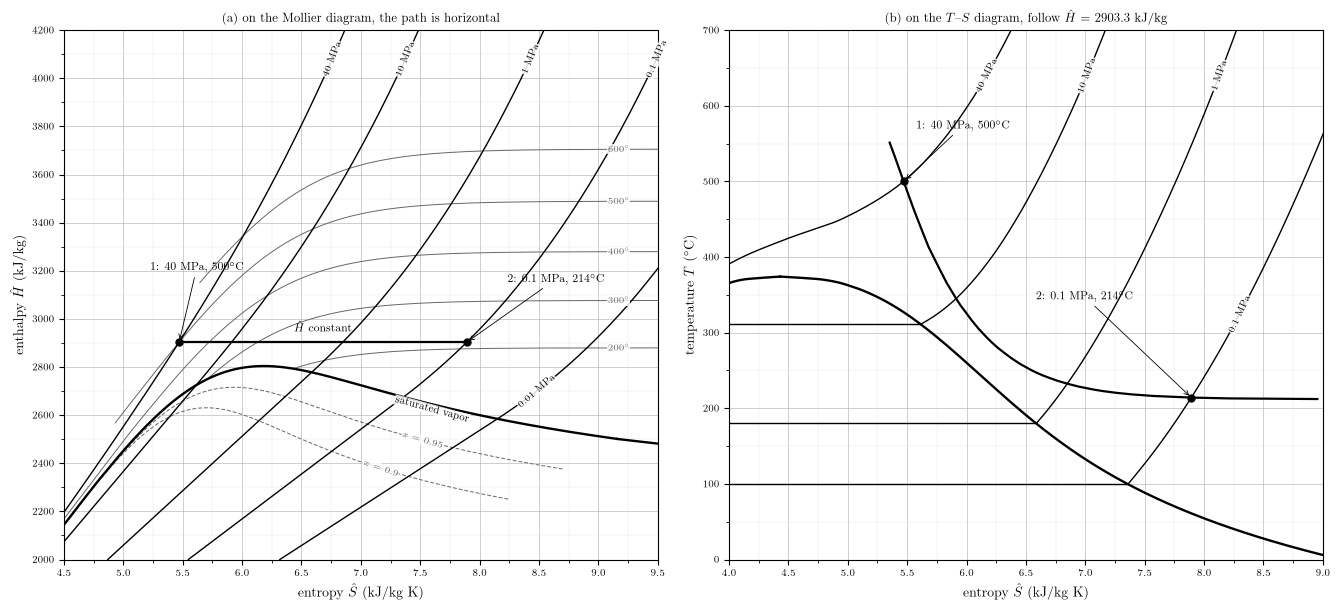

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 6.2))

# --- on the Mollier chart: the path is horizontal -------------------------
ax = axes[0]
# a deliberately sparse version of each chart: the minor line sets are turned off,
# because this panel is a demonstration of how the charts are read, not a chart to
# read values off
mollier(ax, isotherms=(200, 300, 400, 500, 600), isotherms_minor=(),
        qualities=(0.9, 0.95), qualities_minor=(),
        isobars=(0.01, 0.1, 1.0, 10.0, 40.0), isobars_minor=(),
        H_grid=200, grid_minors=2, T_key_title=False)
ax.plot([S1, S2], [H1, H1], "-", color="k", lw=1.6, zorder=7)
ax.plot([S1, S2], [H1, H1], "o", color="k", ms=5, zorder=7)
ax.annotate(f"1: {P1:g} MPa, {T1:g}$^\\circ$C", xy=(S1, H1),
            xytext=(S1 + 0.15, H1 + 300), fontsize=8, ha="center",
            arrowprops=dict(arrowstyle="->", lw=0.6))
ax.annotate(f"2: {P2:g} MPa, {T2_pchip:.0f}$^\\circ$C", xy=(S2, H1),
            xytext=(S2 + 0.75, H1 + 250), fontsize=8, ha="center",
            arrowprops=dict(arrowstyle="->", lw=0.6))
ax.text(0.5 * (S1 + S2), H1 + 45, "$\\hat H$ constant", fontsize=8, ha="center")
ax.set_title("(a) on the Mollier diagram, the path is horizontal", fontsize=9)

# --- on the T-S chart: follow the constant-enthalpy curve -----------------
ax = axes[1]
temperature_entropy(ax, isobars=(0.1, 1.0, 10.0, 40.0), isobars_minor=(),
                    isenthalps=(), isenthalps_minor=(),
                    qualities=(), qualities_minor=(),
                    S_lim=(4, 9), T_lim=(0, 700), mark_critical=False,
                    T_grid=100, grid_minors=2)
for S, T, _ in isenthalp(H1, sorted(sh.P_MPa.unique())):
    ax.plot(S, T, "-", color="k", lw=1.6, zorder=7)
ax.plot([S1, S2], [T1, T2_pchip], "o", color="k", ms=5, zorder=7)
ax.annotate(f"1: {P1:g} MPa, {T1:g}$^\\circ$C", xy=(S1, T1), xytext=(S1 + 0.5, T1 + 70),
            fontsize=8, ha="center", arrowprops=dict(arrowstyle="->", lw=0.6))
ax.annotate(f"2: {P2:g} MPa, {T2_pchip:.0f}$^\\circ$C", xy=(S2, T2_pchip),
            xytext=(S2 - 0.9, T2_pchip + 130), fontsize=8, ha="center",
            arrowprops=dict(arrowstyle="->", lw=0.6))
ax.set_title(f"(b) on the $T$--$S$ diagram, follow $\\hat H$ = {H1:g} kJ/kg",
             fontsize=9)

fig.tight_layout()
fig.savefig("pdf/Illustration_3.4-1_on_both_charts.pdf")
plt.show()

The path on the $T$&ndash;$S$ chart is the same curve the text describes: it drops
steeply at first and then flattens, and the temperature falls by only 286 &deg;C over a
400-fold drop in pressure. Both readings agree with the book's 214.1 &deg;C, and part
(c) reproduces it to the digit.

## What this notebook shows

- **A property chart is a table plus a drawing convention.** Nothing here is fitted or
  correlated. Every curve is a slice of Appendix A.III &mdash; a column, a row, a lever
  rule, or a root found along one of those &mdash; joined with a monotone interpolant.
- **Read a chart along the line the process follows.** A Joule&ndash;Thomson expansion
  is isenthalpic, so on the Mollier diagram it is a horizontal line and on the
  $T$&ndash;$S$ diagram it is a curve you must have drawn for you. That is the whole
  reason two projections of the same data are both printed: each makes a different
  family of processes into a straight line.
- **Data has to be checked before it is drawn.** Three rows of A.III fail
  $P\hat V = \hat H - \hat U$, and they are typos in the printed table, not parse
  errors &mdash; but a *parse* error would have failed the same test, which is why the
  test is run before any curve is plotted. A plausible-looking curve is not evidence.
- **Say where a line stops being data.** Two families here are continued past the last
  tabulated point &mdash; the isotherms below 0.01 MPa and the 60 MPa liquid branch
  &mdash; and both continuations are tested against a table value they were not built
  from before anything is drawn with them.

## Your turn

1. **Read your own problem off the chart.** Problem 3.5 is Illustration 3.4-1 with
   different numbers: steam at 500 bar and 600 &deg;C, expanded to 1 bar. Redraw the
   &sect;5 panels for that state and read $T_2$ off both charts, then get it from the
   table the way part (c) does. How far apart are the three answers, and which digit is
   the first one you should not trust?
2. **Zoom in.** Redraw the Mollier chart with `S_lim=(6.5, 8.0)`, `H_lim=(2400, 3000)`
   and a finer grid (`S_grid=0.1`, `H_grid=25`). That is the wet-steam corner where a
   turbine exit lands. Read the quality of steam at 0.05 MPa and
   $\hat H = 2500$ kJ/kg off your chart, then check it against the lever rule and the
   saturation table.
3. **Make the chart denser, or sparser.** The ASME original labels isotherms every
   20 &deg;C. Move `MOLLIER_T` and `MOLLIER_T_MINOR` to a 25 &deg;C spacing, or strip
   the chart to the eight isobars and five isotherms you would actually use. Print both
   in black and white. Which one can you still read at arm's length, and which one is
   *legible* but no longer *useful*?
4. **Add the line your cycle needs.** Chapter 5 works with power and refrigeration
   cycles, whose four states you plot on the $T$&ndash;$S$ chart. Write a function that
   takes a list of $(P, T)$ states, plots them on `temperature_entropy` in order, and
   closes the loop. Try it on the Rankine cycle of Illustration 5.2-1: condenser at
   100 &deg;C, evaporator at 3.0 MPa, maximum temperature 600 &deg;C, pump and turbine
   reversible. Which of the four legs is vertical, and why?
5. **Break the isotherms on purpose.** In `isotherm`, build the curve by reading the
   table *rows* at that temperature instead of evaluating each isobar. Plot the 650
   &deg;C isotherm both ways. Where does the row-based one stop, and what does looking
   up 650 &deg;C in Appendix A.III tell you about why?
6. **Test a continuation the way &sect;2 does.** The low-pressure continuation assumes
   steam is an ideal gas below 0.01 MPa. Predict the tabulated 0.05 MPa point from the
   0.5 and 0.1 MPa points &mdash; a much longer reach &mdash; and find the temperature
   below which you would not trust it to a line width. What is it about low temperature
   that makes the assumption fail first there?

## 6. The Rankine cycle of Illustration 5.2-1 &mdash; art slot `c05uf001`

Chapter 5's Illustration 5.2-1 runs a steam power cycle with the condenser at 100&nbsp;&deg;C,
the evaporator at 3.0&nbsp;MPa and a maximum temperature of 600&nbsp;&deg;C, and plots it on
*"Fig. 3.3-1b, repeated below."* That repeat is this figure. It belongs here because it **is**
Fig. 3.3-1b, so it should be drawn by the code that draws the chart and move when the chart
moves.

Four states, and every one of them comes out of Appendix A.III &mdash; the same table the
illustration reads, so the figure and its numbers cannot disagree:

| | |
|---|---|
| 1 &rarr; 2 | the feed pump, isentropic. Its whole temperature rise is **0.2&nbsp;K**, so on an 800-degree axis the two states are one pixel |
| 2 &rarr; 3 | isobaric at 3.0&nbsp;MPa: up the liquid line, across the dome at 233.9&nbsp;&deg;C, then into superheat |
| 3 &rarr; 4 | the turbine, isentropic, down to 0.10135&nbsp;MPa |
| 4 &rarr; 1 | isobaric: desuperheat, then condensation at 100&nbsp;&deg;C |

⚠️ **The two interpolated temperatures in the printed table are wrong.** Everything else in it
reproduces exactly &mdash; including the 29.0 % efficiency &mdash; but point 2 is
**100.2&nbsp;&deg;C**, not the *~103* printed, and point 4 is **129.5&nbsp;&deg;C**, not
*~126.2*. Both are the values the 5e marked with a tilde as *"obtained from the steam tables by
interpolation"*, and **the illustration's own Aspen output already disagreed with both**: it
prints 100.2 and 129.6.

point     T (C)   P (MPa)         S         H    the 5e table
1        100.00   0.10135    1.3069    419.04    100      1.3069   419.04
2        100.20   3.00000    1.3069    422.07    ~103     1.3069   422.07   <-- wrong
3        600.00   3.00000    7.5085   3682.30    600      7.5085  3682.3
4        129.45   0.10135    7.5085   2734.83    ~126.2   7.5085  ~2734.7   <-- wrong

W_pump   3.03 [5e 3.03]     W_turbine   -947.5 [5e -947.6]
Q_boiler 3260.2 [5e 3260.2]  Q_condenser  -2315.8 [5e -2315.7]
efficiency 0.2897 = 29.0 %                 [5e 0.290 = 29.0 %]


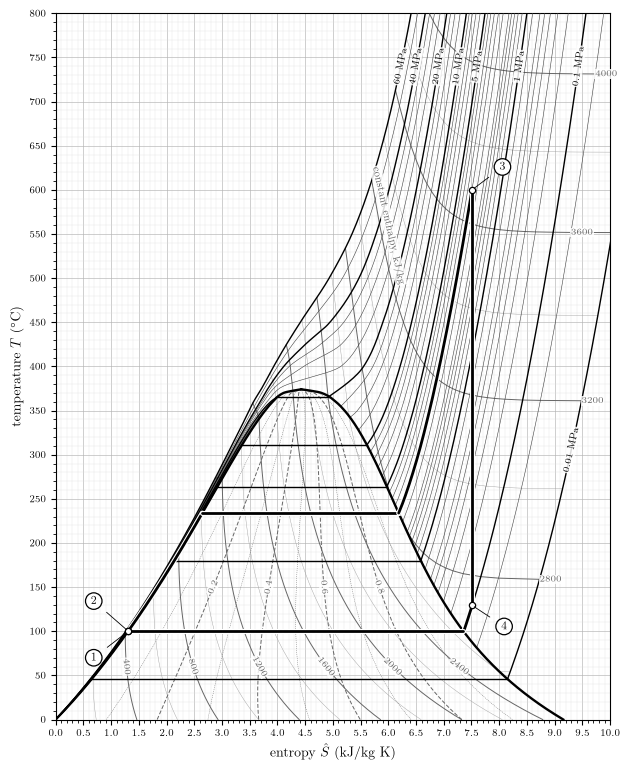

In [12]:
# --- c05uf001: the Rankine cycle of Illustration 5.2-1 on the T-S chart ----
import matplotlib.patheffects as pe

P_LO, P_HI, T_MAX, T1 = 0.10135, 3.0, 600.0, 100.0
row = sat.loc[np.isclose(sat.T_C, T1)].iloc[0]
S1, H1, V1 = float(row.Sl), float(row.Hl), float(row.Vl)
W_pump = V1*(P_HI - P_LO)*1e3                   # m3/kg x MPa -> kJ/kg
H2, S2 = H1 + W_pump, S1

# Point 2's temperature. A.III's compressed-liquid table starts at 5 MPa, so read the
# isentropic rise there and scale it: liquid is near enough incompressible that the
# rise is linear in pressure. It comes to 0.2 K.
_cl5 = cl[np.isclose(cl.P_MPa, 5.0)].dropna(subset=["S", "T_C"]).sort_values("T_C")
T2 = T1 + (float(PchipInterpolator(_cl5.S.values, _cl5.T_C.values)(S1)) - T1) \
     * (P_HI - P_LO)/(5.0 - P_LO)

S_hi, H_hi, T_hi = isobar(P_HI)
S3 = float(PchipInterpolator(T_hi, S_hi)(T_MAX))
H3 = float(PchipInterpolator(T_hi, H_hi)(T_MAX))

# Point 4 sits at 0.10135 MPa, the saturation pressure at 100 C; A.III tabulates 0.1
# and 0.2. Interpolating between the two isobars is worth it -- on 0.1 alone T4 comes
# out a degree low.
def _state_at(P, S):
    Sx, Hx, Tx = isobar(P)
    return (float(PchipInterpolator(Sx, Tx)(S)), float(PchipInterpolator(Sx, Hx)(S)))


(T_a, H_a), (T_b, H_b) = _state_at(0.1, S3), _state_at(0.2, S3)
f = (P_LO - 0.1)/(0.2 - 0.1)
T4, H4 = T_a + f*(T_b - T_a), H_a + f*(H_b - H_a)
eta = -((H4 - H3) + W_pump)/(H3 - H2)

print(f"{'point':<6}{'T (C)':>9}{'P (MPa)':>10}{'S':>10}{'H':>10}    the 5e table")
for n, (T, P, S, H, ref) in enumerate((
        (T1, P_LO, S1, H1, "100      1.3069   419.04"),
        (T2, P_HI, S2, H2, "~103     1.3069   422.07   <-- wrong"),
        (T_MAX, P_HI, S3, H3, "600      7.5085  3682.3"),
        (T4, P_LO, S3, H4, "~126.2   7.5085  ~2734.7   <-- wrong")), 1):
    print(f"{n:<6}{T:9.2f}{P:10.5f}{S:10.4f}{H:10.2f}    {ref}")
print(f"\nW_pump {W_pump:6.2f} [5e 3.03]     W_turbine {H4-H3:8.1f} [5e -947.6]")
print(f"Q_boiler {H3-H2:6.1f} [5e 3260.2]  Q_condenser {H1-H4:8.1f} [5e -2315.7]")
print(f"efficiency {eta:.4f} = {100*eta:.1f} %                 [5e 0.290 = 29.0 %]")

# --- the cycle, leg by leg -------------------------------------------------
Ts = float(Tsat_of_P(P_HI))
Sl_s, Sv_s = float(dome["Sl"](Ts)), float(dome["Sv"](Ts))
Sv_lo = float(dome["Sv"](T1))
Tliq = np.linspace(T2, Ts, 200)      # 3 MPa compressed liquid sits within 0.005
Sliq = dome["Sl"](Tliq)              # kJ/(kg K) of the saturated-liquid line here
m_sh = (T_hi >= Ts) & (T_hi <= T_MAX)
S_lo, H_lo, T_lo = isobar(0.1)
m_lo = (T_lo >= T1) & (T_lo <= T4)
segs = [(np.array([S1, S2]), np.array([T1, T2])),
        (Sliq, Tliq),
        (np.array([Sl_s, Sv_s]), np.array([Ts, Ts])),
        (np.r_[Sv_s, S_hi[m_sh], S3], np.r_[Ts, T_hi[m_sh], T_MAX]),
        (np.array([S3, S3]), np.array([T_MAX, T4])),
        (np.r_[S3, S_lo[m_lo][::-1], Sv_lo], np.r_[T4, T_lo[m_lo][::-1], T1]),
        (np.array([Sv_lo, S1]), np.array([T1, T1]))]

fig, ax = plt.subplots(figsize=(6.4, 7.8))
temperature_entropy(ax)
HALO = [pe.withStroke(linewidth=3.6, foreground="white")]
for S, T in segs:
    ax.plot(S, T, "-", color="k", lw=2.0, zorder=7, path_effects=HALO,
            solid_capstyle="round", solid_joinstyle="round")


def state(lab, S, T, dS, dT):
    """Mark a state where it really is and lead the label away from it.

    Points 1 and 2 are 0.2 K apart -- the pump's entire temperature rise -- so on this
    axis they are the same pixel. Drawing them apart would imply a gap that is not
    there; leading the labels away says the truth.
    """
    ax.plot([S], [T], "o", mfc="white", mec="k", mew=0.9, ms=4.5, zorder=8)
    ax.annotate(lab, xy=(S, T), xytext=(S + dS, T + dT), fontsize=8, ha="center",
                va="center", zorder=9,
                bbox=dict(boxstyle="circle,pad=0.30", fc="white", ec="k", lw=0.9),
                arrowprops=dict(arrowstyle="-", lw=0.6, shrinkA=6, shrinkB=2))


state("1", S1, T1, -0.62, -30)
state("2", S2, T2, -0.62, 34)
state("3", S3, T_MAX, 0.55, 26)
state("4", S3, T4, 0.58, -24)
fig.tight_layout()
fig.savefig("pdf/c05uf001.pdf")                 # the printed figure
plt.show()